In [41]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
from matplotlib import cm
from pathlib import Path
import pandas as pd
from tqdm import tqdm
import seaborn as sns

In [ ]:
# === Configuration ===
data_root = Path("SQUARE")  # adjust to where your results live
output_root = Path("combined_results")
output_root.mkdir(exist_ok=True, parents=True)

# Known parameter arrays
FLEX_STRENGTH_values = [
    0.050, 0.100, 0.150, 0.200, 0.250, 0.300, 0.350, 0.400,
    0.450, 0.500, 0.550, 0.600, 0.650, 0.700, 0.750, 0.800,
    0.850, 0.900, 0.950, 0.980, 0.985, 0.990, 0.995, 1.000
]

S_values = [
    0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1, 1.2, 1.6, 2, 4, 8, 16
]

# --- Helpers ---

def fmt_folder_val(x: float) -> str:
    """
    Format a float for folder name like:
    0.05 -> flex005, 0.1 -> flex01, 0.995 -> flex0995
    """
    if x == 1.0:
        return "10"
    return str(x).replace('.', '')

def fmt_val(x: float) -> str:
    """Format float for filename (S and F inside .npz)"""
    if x == 1.0:
        return "1"
    return str(x).replace('.', 'p')

def combine_arrays(arrs, stds, n=20):
    """Combine replicate means and stds across replicates."""
    arrs = np.stack(arrs)
    stds = np.stack(stds)
    K = arrs.shape[0]
    means = arrs.mean(axis=0)

    SS_within = ((n - 1) * stds**2).sum(axis=0)
    SS_between = (n * (arrs - means)**2).sum(axis=0)

    pooled_var = (SS_within + SS_between) / (K * n - 1)
    pooled_std = np.sqrt(pooled_var)
    return means, pooled_std


# --- Combination loop ---

summary_rows = []
total_tasks = len(FLEX_STRENGTH_values) * len(S_values)

with tqdm(total=total_tasks, desc="Combining simulations", ncols=100) as pbar:
    for F in FLEX_STRENGTH_values:
        f_dir = data_root / f"flex{fmt_folder_val(F)}"
        if not f_dir.exists():
            tqdm.write(f"⚠️  Missing folder for FLEX_STRENGTH={F} ({f_dir})")
            pbar.update(len(S_values))
            continue

        for S in S_values:
            pattern = f"*S{fmt_val(S)}_flex{fmt_val(F)}_*.npz"
            files = list(f_dir.glob(pattern))
            pbar.update(1)

            if not files:
                tqdm.write(f"⚠️  No files for S={S}, F={F}")
                continue

            data = [np.load(f) for f in files]
            keys = ["T0", "T1", "T2", "T3", "CD"]
            combined = {}

            for k in keys:
                means = [d[k] for d in data]
                stds = [d[f"{k}_std"] for d in data]
                m, s = combine_arrays(means, stds)
                combined[k] = m
                combined[f"{k}_std"] = s

            # Save combined time-series .npz
            out_npz = output_root / f"COMBINED_S{fmt_val(S)}_F{fmt_val(F)}.npz"
            np.savez_compressed(out_npz, **combined, S=S, F=F)

            # Store final-timestep summary
            final = {k: combined[k][-1] for k in keys}
            final_std = {f"{k}_std": combined[f"{k}_std"][-1] for k in keys}
            summary_rows.append({"S": S, "F": F, **final, **final_std})

# === Write summary CSV ===
df = pd.DataFrame(summary_rows).sort_values(["F", "S"])
df.to_csv(output_root / "summary_square_final.csv", index=False)

print(f"\n✅ Combined {len(summary_rows)} parameter groups")
print(f"📁 Results saved in: {output_root.resolve()}")

Combining simulations: 100%|██████████████████████████████████████| 384/384 [00:14<00:00, 26.95it/s]


✅ Combined 384 parameter groups
📁 Results saved in: C:\Users\audso\OneDrive\Dokumenter\GitHub\DHT-simulations-misinformation-propagation\N4096\combined_results


C:\Users\audso\AppData\Local\Temp\ipykernel_18840\1425284862.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap("coolwarm", n_bins)


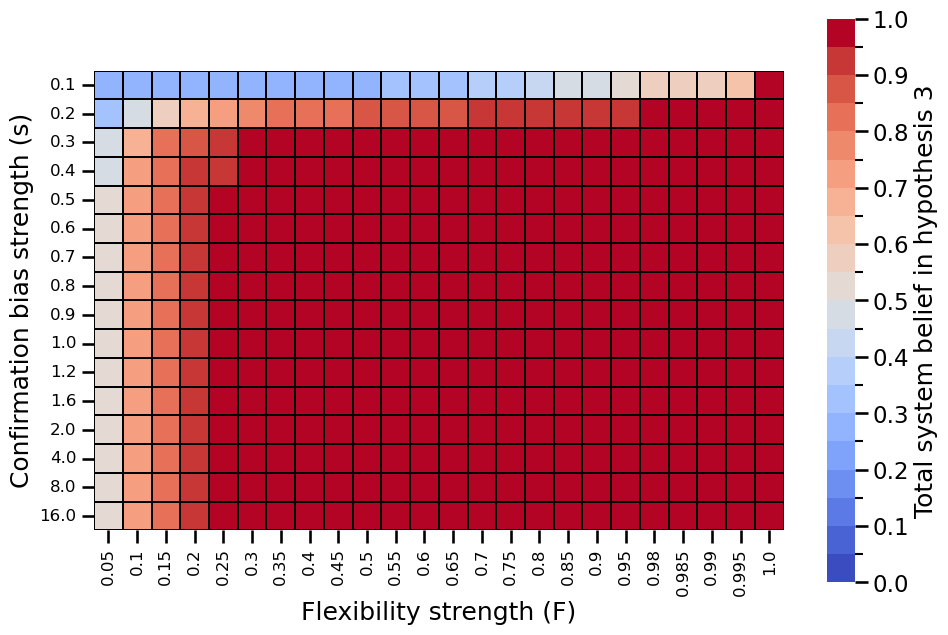

✅ Saved heatmap to plots\heatmap_T3.png


In [117]:
data_path = Path("combined_results/summary_square_final.csv")  # adjust if needed
output_dir = Path("plots")
output_dir.mkdir(exist_ok=True, parents=True)

df = pd.read_csv(data_path)
metric = "T3" 
pivot = df.pivot(index="S", columns="F", values=metric)

vmin, vmax = 0.0, 1.0
n_bins = 20
bounds = np.linspace(vmin, vmax, n_bins + 1)
cmap = cm.get_cmap("coolwarm", n_bins)
norm = BoundaryNorm(boundaries=bounds, ncolors=cmap.N)

pivot = pivot.sort_index(axis=0).sort_index(axis=1)

plt.figure(figsize=(10, 6.7))
sns.set_context("talk")

ax = sns.heatmap(
    pivot,
    cmap=cmap,
    norm=norm,
    cbar_kws={
        "ticks": bounds[::2],
        "label": f"Total system belief in hypothesis {metric[1]}",
    },
    linewidths=0.1,
    linecolor='black',
    square=True
)

# plt.title(f"Heatmap of {metric} (final timestep)")
plt.xlabel("Flexibility strength (F)")
plt.ylabel("Confirmation bias strength (s)")
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
out_path = output_dir / f"heatmap_{metric}.png"
plt.savefig(out_path, dpi=300)
plt.show()

print(f"✅ Saved heatmap to {out_path}")

Processing combined files: 100%|██████████| 384/384 [00:00<00:00, 815.15it/s]
C:\Users\audso\AppData\Local\Temp\ipykernel_18840\3342389618.py:35: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap("coolwarm", n_bins)


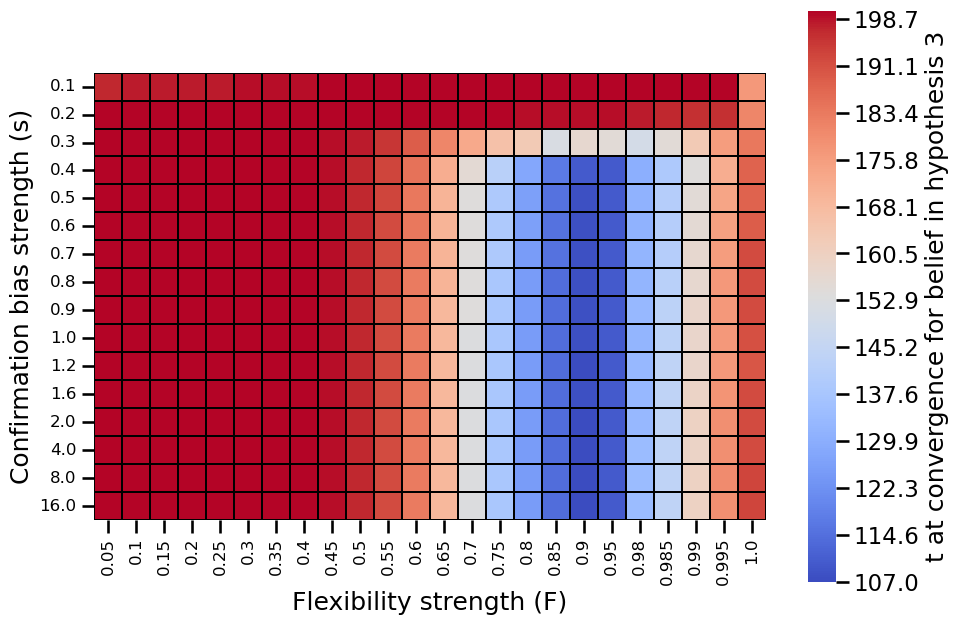

✅ Saved convergence heatmap to plots\convergence_heatmap_T3.png


In [113]:
# === Configuration ===
data_root = Path("combined_results")
output_dir = Path("plots")
output_dir.mkdir(exist_ok=True, parents=True)

metric = "T3"          # change to T1, T2, T3, or CD as needed
threshold = 1e-4       # convergence criterion
n_bins = 10            # discrete color levels
vmin, vmax = 0, 200    # timestep range for color scale (adjust to your simulation length)

# === Load all combined files ===
files = list(data_root.glob("COMBINED_S*_F*.npz"))
rows = []

for f in tqdm(files, desc="Processing combined files"):
    data = np.load(f)
    S, F = data["S"].item(), data["F"].item()
    arr = data[metric]
    final_val = arr[-1]

    # find first timestep within threshold of final value
    diffs = np.abs(arr - final_val)
    conv_idx = np.argmax(diffs < threshold) if np.any(diffs < threshold) else len(arr) - 1
    rows.append({"S": S, "F": F, "converged_at": conv_idx})

# === Build DataFrame ===
df = pd.DataFrame(rows)
pivot = df.pivot(index="S", columns="F", values="converged_at")
pivot = pivot.sort_index(axis=0).sort_index(axis=1)

# === Fixed discrete colormap ===
vmin, vmax = 0.0, 200
n_bins = 200
bounds = np.linspace(vmin, vmax, n_bins + 1)
cmap = cm.get_cmap("coolwarm", n_bins)
norm = BoundaryNorm(boundaries=bounds, ncolors=cmap.N)

# === Plot ===
plt.figure(figsize=(10, 6.7))
sns.set_context("talk")

ax = sns.heatmap(
    pivot,
    cmap="coolwarm",
    vmin=np.min(df["converged_at"]),
    vmax=np.max(df["converged_at"]),
    # norm=norm,
    cbar_kws={
        "ticks": np.linspace(np.min(df["converged_at"]), 214, 15),
        "label": f"t at convergence for belief in hypothesis {metric[1]}",
    },
    linewidths=0.1,
    linecolor='black',
    square=True
)

# plt.title(f"Heatmap of {metric} (final timestep)")
plt.xlabel("Flexibility strength (F)")
plt.ylabel("Confirmation bias strength (s)")
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
out_path = output_dir / f"convergence_heatmap_{metric}.png"
plt.savefig(out_path, dpi=300)
plt.show()


print(f"✅ Saved convergence heatmap to {out_path}")
